In [ ]:
#se instala para poder separar las imagenes

In [ ]:
#imports
import tensorflow as tf
import keras
import os
#librerias para el entrenamiento del modelo
from keras.models import Sequential, load_model
from keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, Input

#librerias para mostrar los cambios de la funcion loss
from keras.src.legacy.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import splitfolders #para separar el dataset en dif carpetas mientras se entrena todo
import cv2

from keras import layers, models
from keras.applications.resnet50 import preprocess_input

os.environ['CUDA_VISIBLE_DEVICES'] = "0" #para que no salga mensaje de error

In [31]:
input_folder = "dataset"
output_folder = "image-recognition"

In [ ]:

split_ratio = (0.8, 0.1, 0.1) #80% imagenes entrenadas, 10% testing, 10% validacion


splitfolders.ratio(
    input_folder,
    output= output_folder,
    seed = 500, #para que cada ves que de dividan las imgs se haga de la misma forma
    ratio = split_ratio,
    group_prefix = None
)


In [ ]:
#img_size = (130, 162)
img_size = (224, 224)

batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function= preprocess_input, #usa la funcion preprocess input de resNet50
    rotation_range=20, #rota las imagenes aleatoreamente
    width_shift_range=0.2, # mueve la imagen de izquierda a la derecha aleatoriamente
    height_shift_range=0.2, #mueve la imagen arriba o abajo aleatoriamente
    shear_range=0.2,
    zoom_range= 0.2,
    horizontal_flip=True,
    fill_mode= 'nearest'
)

In [34]:
#ambas reescalan las imagenes para que los datos se mantengan
#aumento de datos para datos de testeo
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

#aumento de datos para datos de validacion
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [35]:

train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

#lee los datos de las carpetas y las prepara en tandas para entrenar el modelo
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size, 
    batch_size=batch_size,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 134 images belonging to 5 classes.
Found 25 images belonging to 5 classes.
Found 30 images belonging to 5 classes.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..113.32].


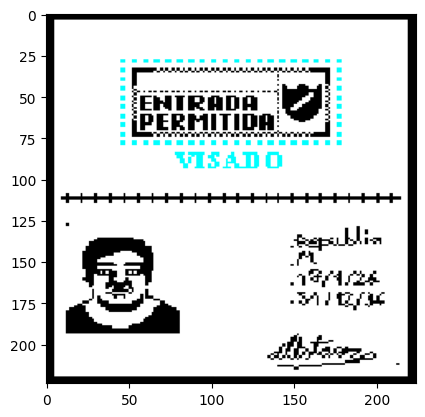

In [50]:
import random
images, labels = next(valid_data)
idx = random.randint(0,images.shape[0]-1)

plt.imshow(images[idx])
plt.show()

In [37]:
from keras.applications.resnet import ResNet50 #es una cnn que esta entrenada en distintas categorias

base_model = ResNet50(weights='imagenet',include_top=False,input_shape=(img_size[0], img_size[1], 3))
#top son clasificaciones, sin el podemos poner las que se necesiten

#razones :/
base_model.trainable = False

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), #ambas son fully connected layers
    layers.Dense(128, activation='relu'), #128 neuronas, con funcion de activacion relu
    layers.Dropout(0.5), # desactiva de forma aleatorea 50% de las variables de entrada
    layers.Dense(5, activation='softmax') #5 neuronas, funcion de activacion softmax
])


Compilacion del modelo

In [39]:
model.compile(optimizer='adam', #adaptive moment estimation, es eficiente
    loss='categorical_crossentropy',
    metrics=['accuracy'])

Entrenamiento del modelo

In [ ]:
import scipy
model.fit(train_data, epochs=100, validation_data=valid_data)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2313 - loss: 1.9192 - val_accuracy: 0.2800 - val_loss: 1.5517
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3507 - loss: 1.7697 - val_accuracy: 0.5200 - val_loss: 1.2964
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 840ms/step - accuracy: 0.4030 - loss: 1.4531 - val_accuracy: 0.4800 - val_loss: 1.2820
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3881 - loss: 1.4764 - val_accuracy: 0.4400 - val_loss: 1.2570
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 864ms/step - accuracy: 0.5000 - loss: 1.2065 - val_accuracy: 0.5200 - val_loss: 1.1952
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 872ms/step - accuracy: 0.5149 - loss: 1.2232 - val_accuracy: 0.4400 - val_loss: 1.2043
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 839ms/step - accuracy: 0.5075 - loss: 1.1177 - val_accuracy: 0.4400 - val_loss: 1.1760
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 864ms/step - accuracy: 0.5224 - loss: 1.0754 - val_accuracy: 0.4800 - val_loss:

Evalucion del modelo

In [41]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f'Presicion de la prueba: {test_accuracy * 100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step - accuracy: 0.6333 - loss: 1.0781
Presicion de la prueba: 63.33%


In [42]:
class_names = {0: 'no-visado', 1: 'pasaporte-valido', 2: 'sin-firma', 3: 'sin-imagen', 4: 'sin-texto'}

In [51]:
def predict_img(image, model):
    test_img=cv2.imread(image)
    test_img=cv2.resize(test_img, (224,224))
    test_img=np.expand_dims(test_img, axis=0)
    result=model.predict(test_img)
    r=np.argmax(result)
    print(class_names[r])

In [45]:
predict_img('image-recognition/test/pasaporte-valido/psp_united_6', model)

[ WARN:0@3201.631] global loadsave.cpp:278 findDecoder imread_('image-recognition/test/pasaporte-valido/psp_united_6'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'
